# Solar Energy Data Analysis & Power Prediction 📊⚡

## Project Objective  
The aim of this project is to perform exploratory data analysis (EDA) on solar-related environmental data and build a machine learning model to predict **generated solar power (kW)** based on atmospheric conditions.

## Tools & Libraries  
- Python  
- Pandas, NumPy  
- Matplotlib, Seaborn  
- scikit-learn  

##  Workflow  
1. Data Loading and Inspection  
2. Exploratory Data Analysis (EDA)  
3. Linear Regression Model to Predict `generated_power_kw`  
4. Model Evaluation and Insights  



In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [10]:
#load the data
solar_df=pd.read_csv("spg.csv")
solar_df.head() 

,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,2.17,31,1035.0,0.0,0.0,0.0,0,0,0,0.00,...,312.71,9.36,22.62,6.62,337.62,24.48,58.753108,83.237322,128.33543,454.10095
1,2.31,27,1035.1,0.0,0.0,0.0,0,0,0,1.78,...,294.78,5.99,32.74,4.61,321.34,21.96,45.408585,75.143041,139.65530,1411.99940
2,3.65,33,1035.4,0.0,0.0,0.0,0,0,0,108.58,...,270.00,3.89,56.31,3.76,286.70,14.04,32.848282,68.820648,152.53769,2214.84930
3,5.82,30,1035.4,0.0,0.0,0.0,0,0,0,258.10,...,323.13,3.55,23.96,3.08,339.44,19.80,22.699288,64.883536,166.90159,2527.60920
4,7.73,27,1034.4,0.0,0.0,0.0,0,0,0,375.58,...,10.01,6.76,25.20,6.62,22.38,16.56,19.199908,63.795208,182.13526,2640.20340


In [11]:
#check the shape of the data
solar_df.shape

(4213, 21)

In [ ]:
# see the basic info
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4213 entries, 0 to 4212
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4213 non-null   float64
 1   relative_humidity_2_m_above_gnd    4213 non-null   int64  
 2   mean_sea_level_pressure_MSL        4213 non-null   float64
 3   total_precipitation_sfc            4213 non-null   float64
 4   snowfall_amount_sfc                4213 non-null   float64
 5   total_cloud_cover_sfc              4213 non-null   float64
 6   high_cloud_cover_high_cld_lay      4213 non-null   int64  
 7   medium_cloud_cover_mid_cld_lay     4213 non-null   int64  
 8   low_cloud_cover_low_cld_lay        4213 non-null   int64  
 9   shortwave_radiation_backwards_sfc  4213 non-null   float64
 10  wind_speed_10_m_above_gnd          4213 non-null   float64
 11  wind_direction_10_m_above_gnd      4213 non-null   float

In [ ]:
#missing value
solar_df.isna().sum()

temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_direction_10_m_above_gnd        0
wind_speed_80_m_above_gnd            0
wind_direction_80_m_above_gnd        0
wind_speed_900_mb                    0
wind_direction_900_mb                0
wind_gust_10_m_above_gnd             0
angle_of_incidence                   0
zenith                               0
azimuth                              0
generated_power_kw                   0
dtype: int64


##  Exploratory Data Analysis (EDA)
We will now explore the dataset using various visualizations to understand the distribution and relationships among variables.


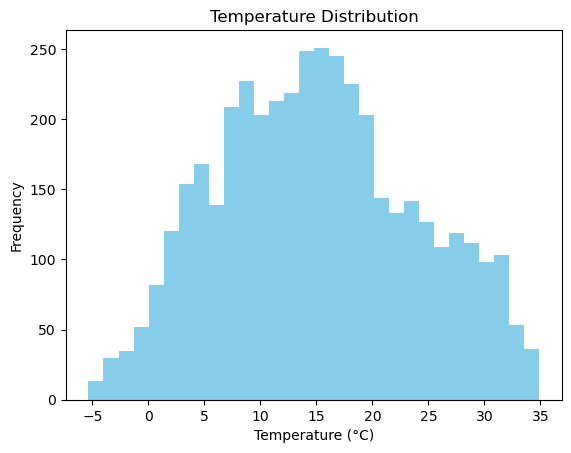

In [19]:

#  Histogram of Temperature
solar_df["temperature_2_m_above_gnd"].plot.hist(bins=30, color='skyblue')
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

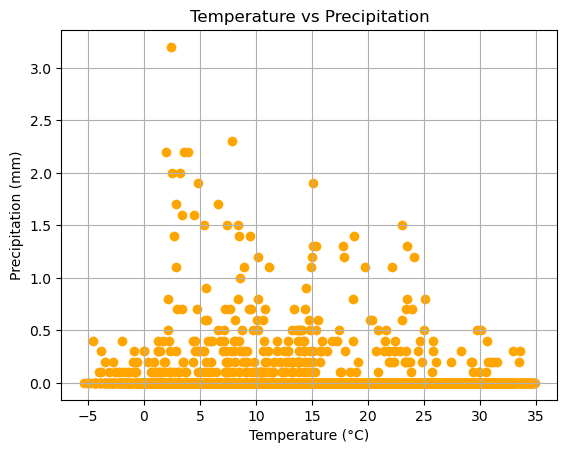

In [21]:
# Scatter plot: Temperature vs. Precipitation
plt.scatter(solar_df["temperature_2_m_above_gnd"], solar_df["total_precipitation_sfc"], color='orange')
plt.title("Temperature vs Precipitation")
plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()



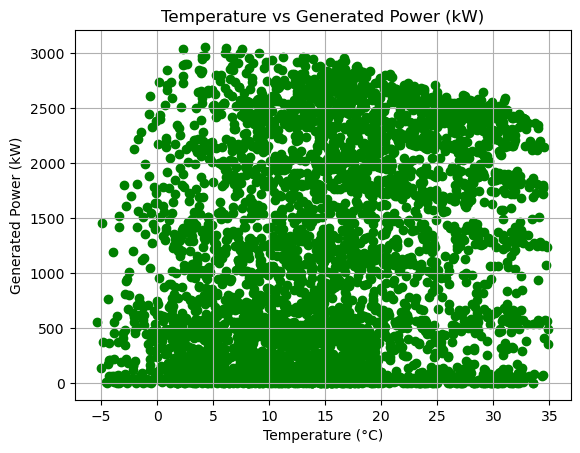

In [ ]:

# Temperature vs Power Generated Scatterplot
plt.scatter(solar_df["temperature_2_m_above_gnd"], solar_df["generated_power_kw"], color='green')
plt.title("Temperature vs Generated Power (kW)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Generated Power (kW)")
plt.grid(True)
plt.show()



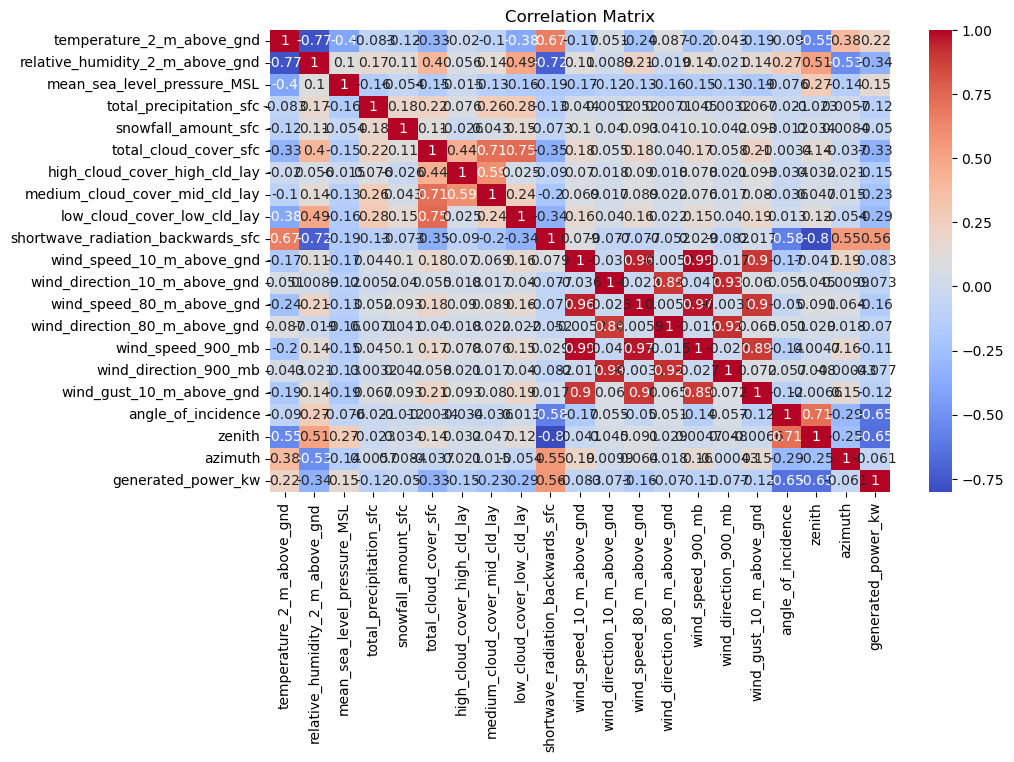

In [24]:
#Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(solar_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


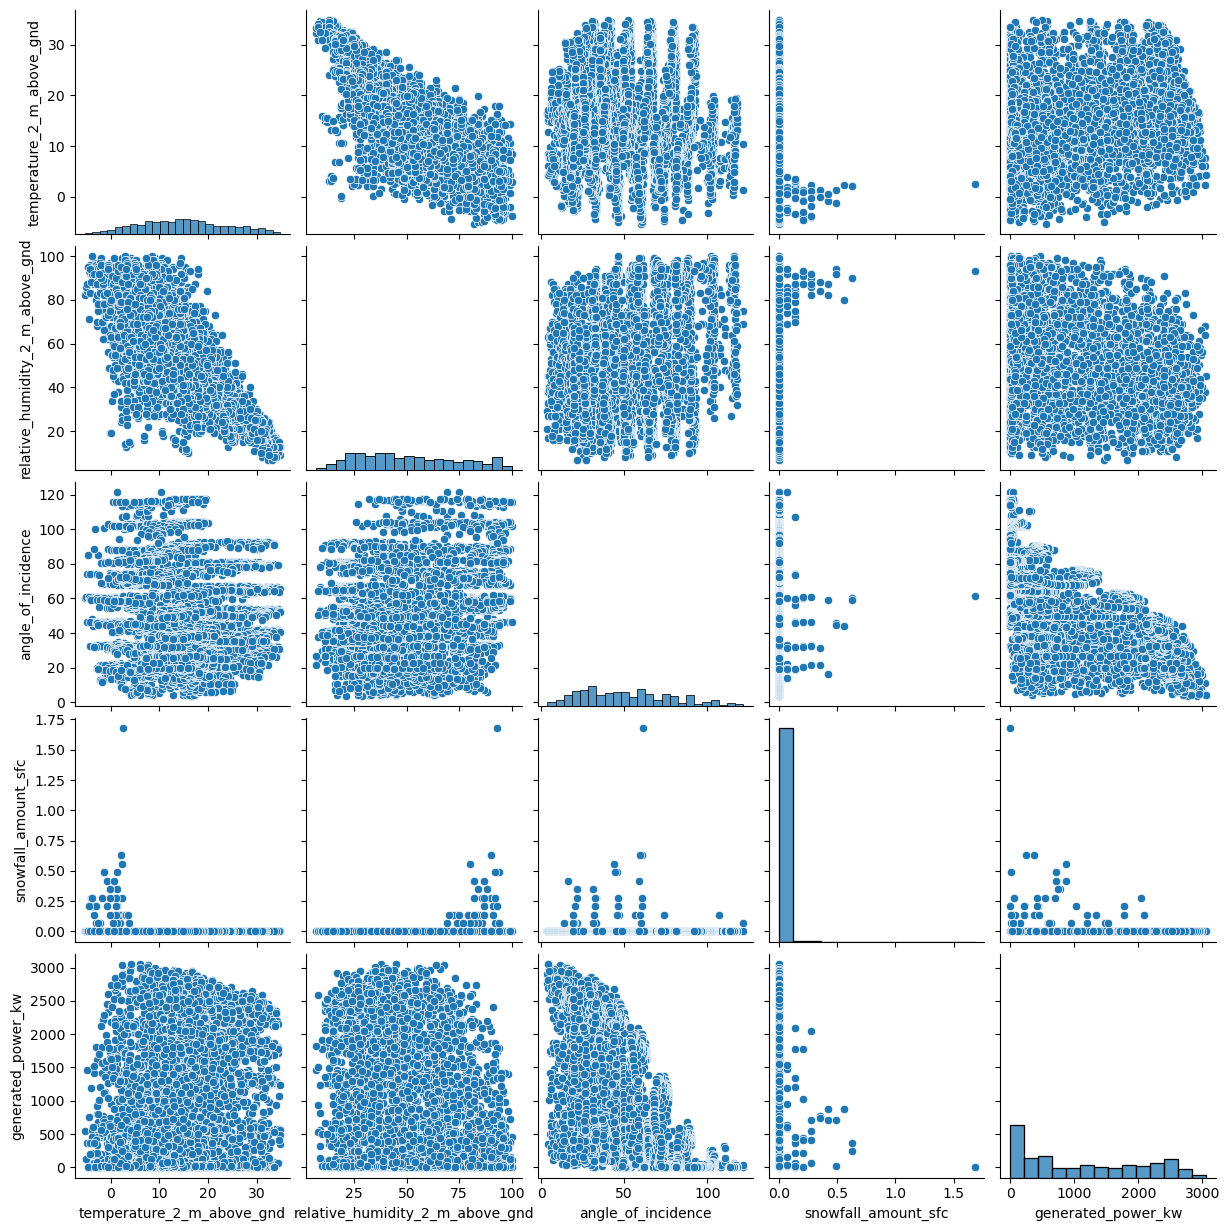

In [26]:
#  Pairplot
sns.pairplot(solar_df[["temperature_2_m_above_gnd", "relative_humidity_2_m_above_gnd", 
                 "angle_of_incidence", "snowfall_amount_sfc", "generated_power_kw"]])
plt.show()


##  Predicting Generated Solar Power (kW) with Linear Regression
We’ll use environmental features to predict `generated_power_kw`.


In [28]:
# features and target selaction
features = ["temperature_2_m_above_gnd", "relative_humidity_2_m_above_gnd",
            "angle_of_incidence", "snowfall_amount_sfc"]
target = "generated_power_kw"

X = solar_df[features]
y = solar_df[target]


In [29]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
# Model Training
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [32]:
#Prediction
y_pred = lr_model.predict(X_test)


In [33]:
# Model Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))


R2 Score: 0.4660780823518761
Mean Absolute Error (MAE): 603.0293964507708
Mean Squared Error (MSE): 487718.3261188966


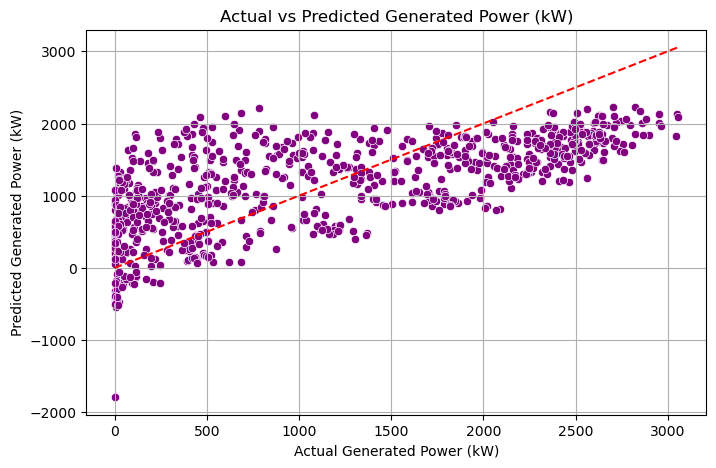

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Generated Power (kW)")
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.grid(True)
plt.show()


## Project Conclusion & Insights

- Temperature, humidity, and angle of incidence moderately correlate with solar power generation.
- Our Linear Regression model achieved an **R² score of around 0.46**, meaning it explains roughly 46% of the variance in power output based on these features.
- Model performance can be improved by:
  - Including additional features (cloud cover, irradiance if available)
  - Applying multiple regression or advanced models (Random Forest, Gradient Boosting)
  - Feature engineering and interaction terms


In [35]:
new_data = pd.DataFrame({
    "temperature_2_m_above_gnd": [25],
    "relative_humidity_2_m_above_gnd": [45],
    "angle_of_incidence": [32],
    "snowfall_amount_sfc": [0]
})

predicted_power = lr_model.predict(new_data)
print("Predicted Power (kW):", predicted_power[0])

Predicted Power (kW): 1636.5718869848524
